# **Lista de exercícios 2**: Modelo Probabilístico de Regressão Linear

Prof. Dr. Rodrigo Colnago Contreras <br />
contreras@unifesp.br

Para a condução das práticas computacionais, é necessário instalar a biblioteca ```yfinance```:

In [1]:
!pip install yfinance --upgrade --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.7/133.7 kB 3.8 MB/s eta 0:00:00


Sugere-se utilizar a função abaixo para confeccionar o dataframe com os ativos financeiros considerados.

In [2]:
import yfinance as yf
import pandas as pd

def montar_dataframe_yfinance(inicio='2023-04-01', fim='2024-04-01'):
    ativos = {
        'BTC': 'BTC-USD', # Bitcoin
        'ETH': 'ETH-USD', # Etherium
        'SP500': '^GSPC', # Standard & Poor's 500, ou simplesmente S&P, trata-se de um índice composto por quinhentos ativos cotados nas bolsas de NYSE ou NASDAQ
        'DXY': 'DX-Y.NYB' # Índice do dolar americano
    }

    dfs = []
    for nome, ticker in ativos.items():
        print(f"\nBaixando dados de {nome} ({ticker})...")
        try:
            df_temp = yf.download(ticker, start=inicio, end=fim)
            if 'Close' not in df_temp.columns:
                print(f"⚠️ Dados indisponíveis para {ticker}. Ignorando.")
                continue
            df_temp = df_temp[['Close']].rename(columns={'Close': nome})
            df_temp['date'] = df_temp.index.date
            dfs.append(df_temp.reset_index(drop=True))
        except Exception as e:
            print(f"❌ Erro ao baixar {ticker}: {e}")

    if not dfs:
        raise ValueError("❌ Nenhum dado foi carregado com sucesso.")

    df_final = dfs[0]
    for df in dfs[1:]:
        df_final = pd.merge(df_final, df, on='date', how='inner')

    return df_final


Exemplo de coleta de ativos com a ```yfinance```:

In [3]:
df_ativos = montar_dataframe_yfinance()
df_ativos


Baixando dados de BTC (BTC-USD)...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



Baixando dados de ETH (ETH-USD)...

Baixando dados de SP500 (^GSPC)...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



Baixando dados de DXY (DX-Y.NYB)...


Price,BTC,date,ETH,SP500,DXY
Ticker,BTC-USD,,ETH-USD,^GSPC,DX-Y.NYB
0,27790.220703,2023-04-03,1810.297119,4124.509766,102.089996
1,28168.089844,2023-04-04,1871.005127,4100.600098,101.589996
2,28177.984375,2023-04-05,1909.114014,4090.379883,101.849998
3,28044.140625,2023-04-06,1872.922607,4105.020020,101.820000
4,29652.980469,2023-04-10,1911.207520,4109.109863,102.580002
...,...,...,...,...,...
244,63778.761719,2024-03-22,3333.687988,5234.180176,104.430000
245,69958.812500,2024-03-25,3590.883789,5218.189941,104.230003
246,69987.835938,2024-03-26,3587.504883,5203.580078,104.290001


## **Exercício 1:** Quais ativos dentre o preço de fechamento do bitcoin, da etherium, da SP500 e da DXY correlacionam-se de maneira aproximadamente linear?

**Dica**: Analise o *scatter plot* destes ativos.

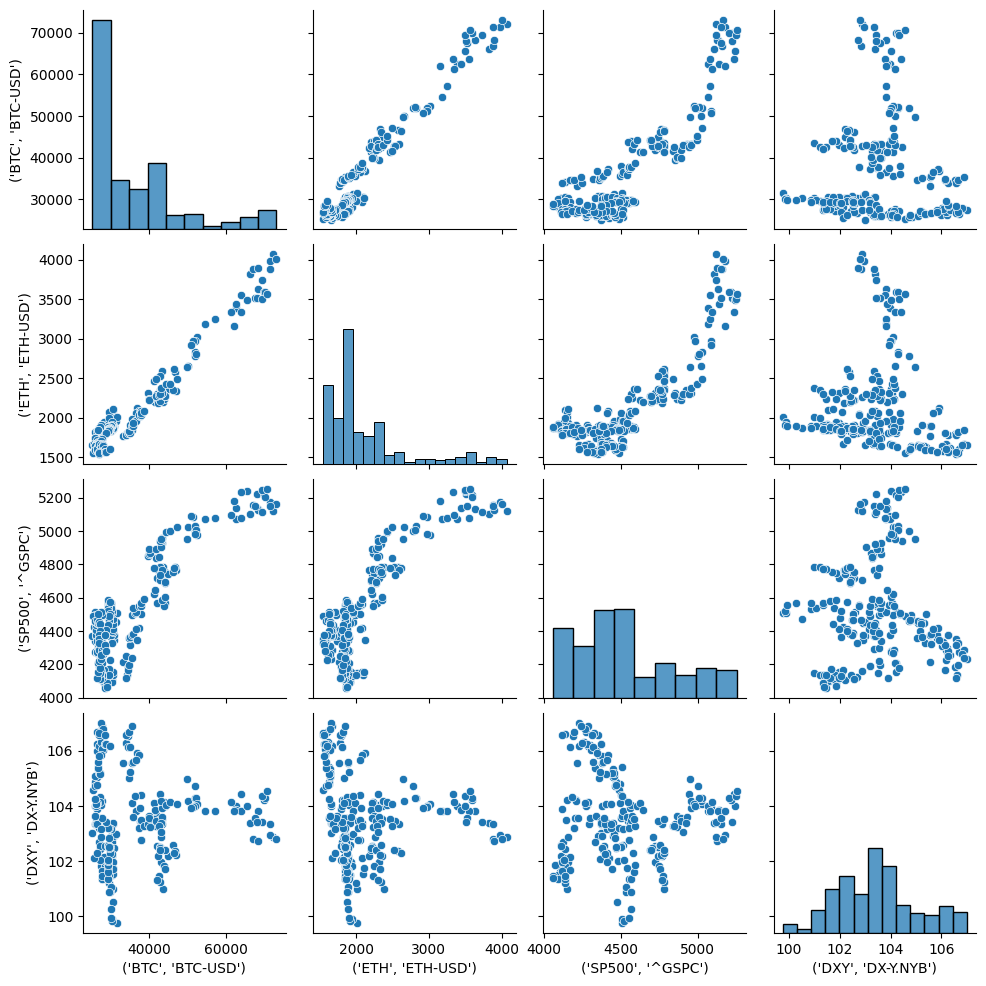

In [4]:
# prompt: codigo para gerar grafico scatter pareado de um dataframe

import matplotlib.pyplot as plt
import seaborn as sns

# Criar o gráfico de dispersão pareado
sns.pairplot(df_ativos[['BTC', 'ETH', 'SP500', 'DXY']])
plt.show()


## **Exercício 2:** Calcule a reta que descreve o preço de fechamento do BTC em função do preço de fechamento da ETH utilizando um MPRL determinado pelo método de mínimos quadrados. Analise a qualidade das métricas numéricas e visuais dessa aproximação.

**Dica:** Utilize as funções confeccionadas em sala de aula.

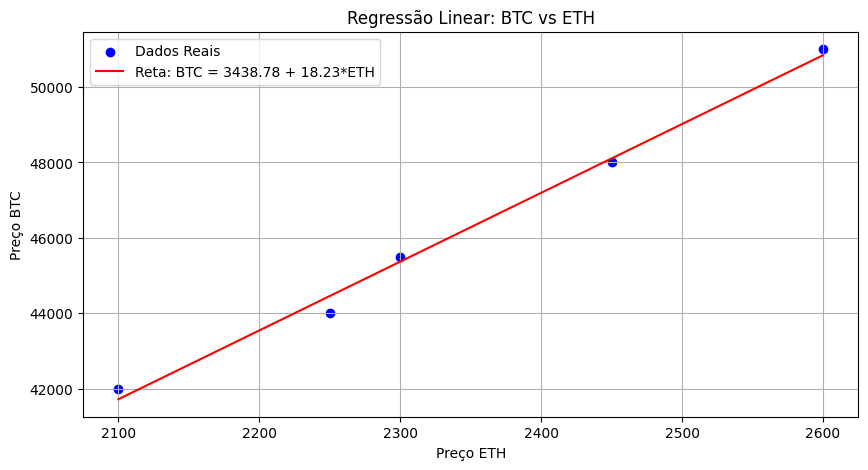

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def calcular_mprl(x, y):
    x_mean, y_mean = np.mean(x), np.mean(y)
    numerador = np.sum((x - x_mean) * (y - y_mean))
    denominador = np.sum((x - x_mean)**2)
    beta_1 = numerador / denominador
    beta_0 = y_mean - beta_1 * x_mean
    return beta_0, beta_1

# 1. Certifique-se que estas variáveis existem!
# Se vierem de um DataFrame df, use: eth_precos = df['ETH'].values
eth_precos = np.array([2100, 2250, 2300, 2450, 2600])
btc_precos = np.array([42000, 44000, 45500, 48000, 51000])

# 2. Cálculos
b0, b1 = calcular_mprl(eth_precos, btc_precos)
y_pred = b0 + b1 * eth_precos  # Valores preditos pela reta

# 3. Visualização
plt.figure(figsize=(10, 5))
plt.scatter(eth_precos, btc_precos, color='blue', label='Dados Reais')
plt.plot(eth_precos, y_pred, color='red', label=f'Reta: BTC = {b0:.2f} + {b1:.2f}*ETH')
plt.xlabel('Preço ETH')
plt.ylabel('Preço BTC')
plt.title('Regressão Linear: BTC vs ETH')
plt.legend()
plt.grid(True)
plt.show()

## **Exercício 3:** Calcule a reta que descreve o preço de fechamento do BTC em função do preço de fechamento dos demais ativos coletados no Exercício 1 utilizando um MPRL múltiplo determinado pelo método de mínimos quadrados. Analise a qualidade das métricas numéricas e visuais dessa aproximação.

**Dica:** Utilize as funções confeccionadas em sala de aula.


Calculando coeficientes de regressão...

Coeficiente Intercepto (beta_0): -106901.2730
Coeficiente ETH (beta_1): 17.5435
Coeficiente SP500 (beta_2): 7.2621
Coeficiente DXY (beta_3): 707.4371

--- Métricas Numéricas da Aproximação ---
R² (Coeficiente de Determinação): 0.9674
MSE (Erro Quadrático Médio): 4802507.68
RMSE (Raiz do Erro Quadrático Médio): 2191.46
MAE (Erro Absoluto Médio): 1758.38


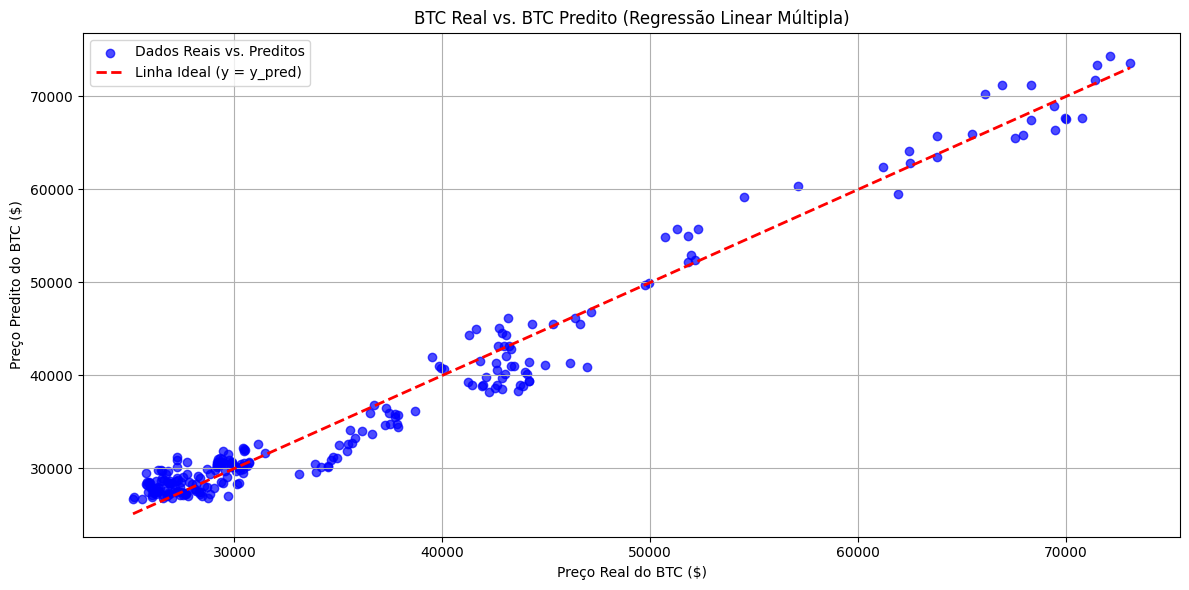

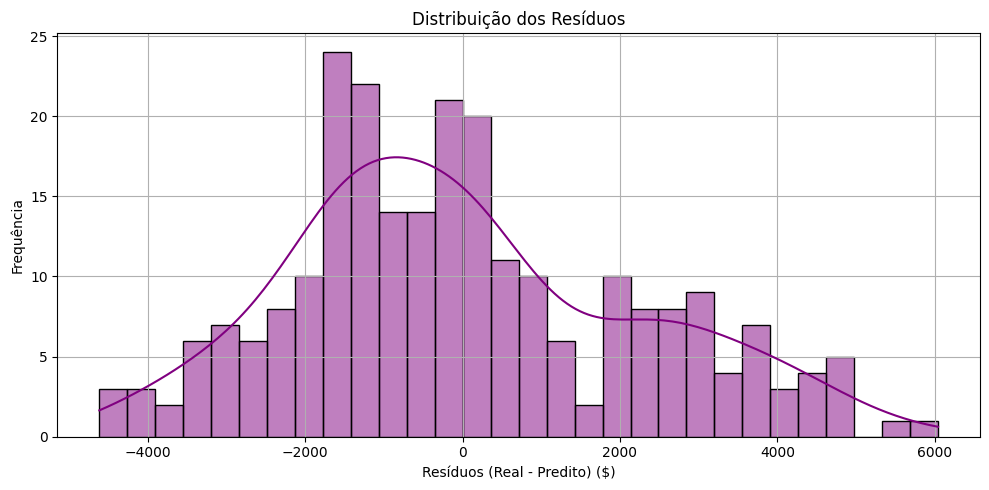

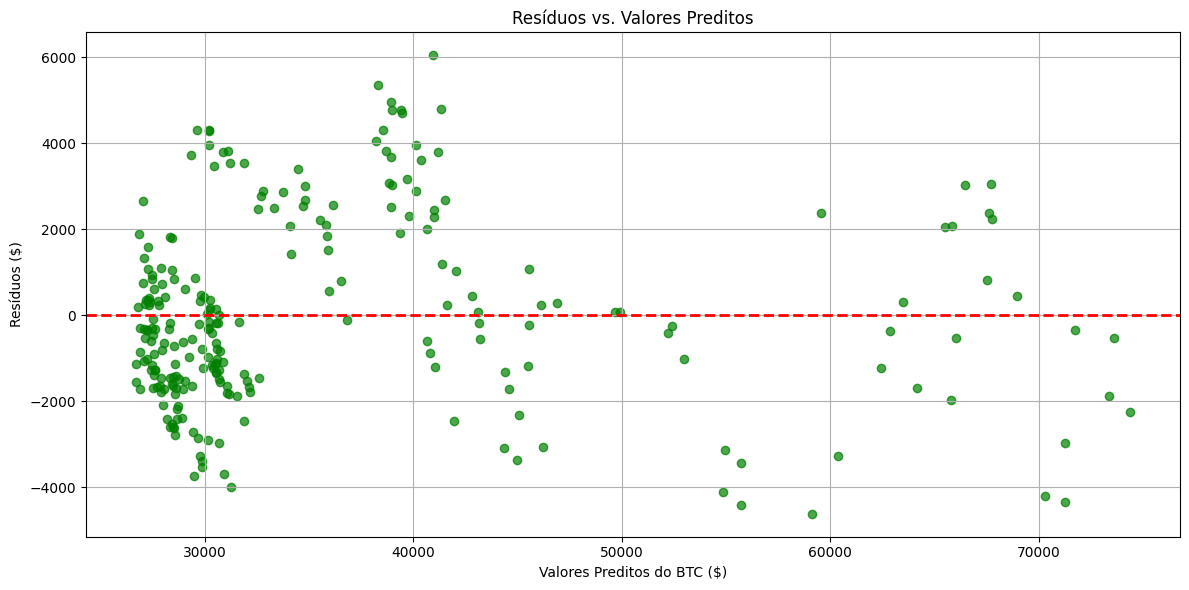


--- Equação da Regressão Múltipla ---
BTC_pred = -106901.2730 + 17.5435 * ETH + 7.2621 * SP500 + 707.4371 * DXY


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Certifique-se que df_ativos está disponível
# Se não estiver, esta parte irá recarregá-lo.
if 'df_ativos' not in locals() or df_ativos.empty:
    print("DataFrame 'df_ativos' não encontrado ou vazio. Carregando dados...")
    try:
        # Supondo que a função montar_dataframe_yfinance() esteja definida em uma célula anterior
        df_ativos = montar_dataframe_yfinance()
        print("DataFrame 'df_ativos' carregado com sucesso.")
    except NameError:
        print("Erro: A função 'montar_dataframe_yfinance' não está definida. Execute as células anteriores.")
        raise
    except Exception as e:
        print(f"Erro ao carregar df_ativos: {e}")
        raise

# 1. Preparar os dados
y = df_ativos['BTC'].values.reshape(-1, 1) # Variável dependente (Preço do BTC) - reshape para garantir que é coluna
X_vars = df_ativos[['ETH', 'SP500', 'DXY']].values # Variáveis independentes

# Adicionar uma coluna de uns para o termo de intercepto (beta_0) na matriz X
X = np.c_[np.ones(X_vars.shape[0]), X_vars]

# 2. Calcular os coeficientes de regressão usando o método de mínimos quadrados (forma matricial)
print("\nCalculando coeficientes de regressão...\n")
try:
    # beta = (X.T @ X)^-1 @ X.T @ y
    # np.linalg.inv para a inversa da matriz, @ para multiplicação de matrizes
    beta_coefficients = np.linalg.inv(X.T @ X) @ X.T @ y
except np.linalg.LinAlgError:
    print("Erro: A matriz (X.T @ X) é singular. Isso pode indicar multicolinearidade perfeita.")
    print("Utilizando LinearRegression do scikit-learn como alternativa para robustez.")
    from sklearn.linear_model import LinearRegression
    model = LinearRegression()
    model.fit(X_vars, y) # scikit-learn LinearRegression adiciona o intercepto automaticamente
    beta_coefficients = np.concatenate(([model.intercept_], model.coef_.flatten())) # Usar .flatten() para obter 1D

# Extrair os coeficientes
beta_0 = beta_coefficients[0][0]
beta_eth = beta_coefficients[1][0]
beta_sp500 = beta_coefficients[2][0]
beta_dxy = beta_coefficients[3][0]

print(f"Coeficiente Intercepto (beta_0): {beta_0:.4f}")
print(f"Coeficiente ETH (beta_1): {beta_eth:.4f}")
print(f"Coeficiente SP500 (beta_2): {beta_sp500:.4f}")
print(f"Coeficiente DXY (beta_3): {beta_dxy:.4f}")

# 3. Fazer as previsões
y_pred = X @ beta_coefficients

# 4. Analisar a qualidade das métricas numéricas
r_squared = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)

print("\n--- Métricas Numéricas da Aproximação ---")
print(f"R² (Coeficiente de Determinação): {r_squared:.4f}")
print(f"MSE (Erro Quadrático Médio): {mse:.2f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse:.2f}")
print(f"MAE (Erro Absoluto Médio): {mae:.2f}")

# 5. Analisar a qualidade visual da aproximação

# Gráfico 1: Valores Reais vs. Valores Preditos
plt.figure(figsize=(12, 6))
plt.scatter(y, y_pred, alpha=0.7, color='blue', label='Dados Reais vs. Preditos')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Linha Ideal (y = y_pred)')
plt.xlabel("Preço Real do BTC ($)")
plt.ylabel("Preço Predito do BTC ($)")
plt.title("BTC Real vs. BTC Predito (Regressão Linear Múltipla)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Cálculo e visualização dos resíduos
residuals = y.flatten() - y_pred.flatten() # Flatten para garantir que são 1D para histplot

# Gráfico 2: Distribuição dos Resíduos
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, bins=30, color='purple')
plt.xlabel("Resíduos (Real - Predito) ($)")
plt.ylabel("Frequência")
plt.title("Distribuição dos Resíduos")
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico 3: Resíduos vs. Valores Preditos (para verificar homocedasticidade e linearidade)
plt.figure(figsize=(12, 6))
plt.scatter(y_pred, residuals, alpha=0.7, color='green')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel("Valores Preditos do BTC ($)")
plt.ylabel("Resíduos ($)")
plt.title("Resíduos vs. Valores Preditos")
plt.grid(True)
plt.tight_layout()
plt.show()

# Print da equação da reta de regressão múltipla
print("\n--- Equação da Regressão Múltipla ---")
print(f"BTC_pred = {beta_0:.4f} + {beta_eth:.4f} * ETH + {beta_sp500:.4f} * SP500 + {beta_dxy:.4f} * DXY")

## **Exercício 4:** Calcule a reta que descreve o preço de fechamento do ETH em função do preço de fechamento dos ativos SP500 e DXY coletados no Exercício 1 utilizando um MPRL múltiplo determinado pelo método de mínimos quadrados.

(a) Analise a qualidade das métricas numéricas e visuais dessa aproximação.

(b) Colete valores de 02 a 10 de abril de 2024 para os ativos coletados no Exercício 1 e os armazene em um *dataframe* ```df_teste```.

(c) Utilizando valores de SP500 e DXY referente ao período mencionado no item (b) anterior, estime os valores de ETH.


--- Exercício 4 (a): Regressão Linear Múltipla para ETH ---

Calculando coeficientes de regressão para ETH...

Coeficiente Intercepto (beta_0): -1531.1240
Coeficiente SP500 (beta_1): 1.4989
Coeficiente DXY (beta_2): -30.3086

--- Métricas Numéricas da Aproximação para ETH ---
R² (Coeficiente de Determinação): 0.7102
MSE (Erro Quadrático Médio): 93811.93
RMSE (Raiz do Erro Quadrático Médio): 306.29
MAE (Erro Absoluto Médio): 253.68


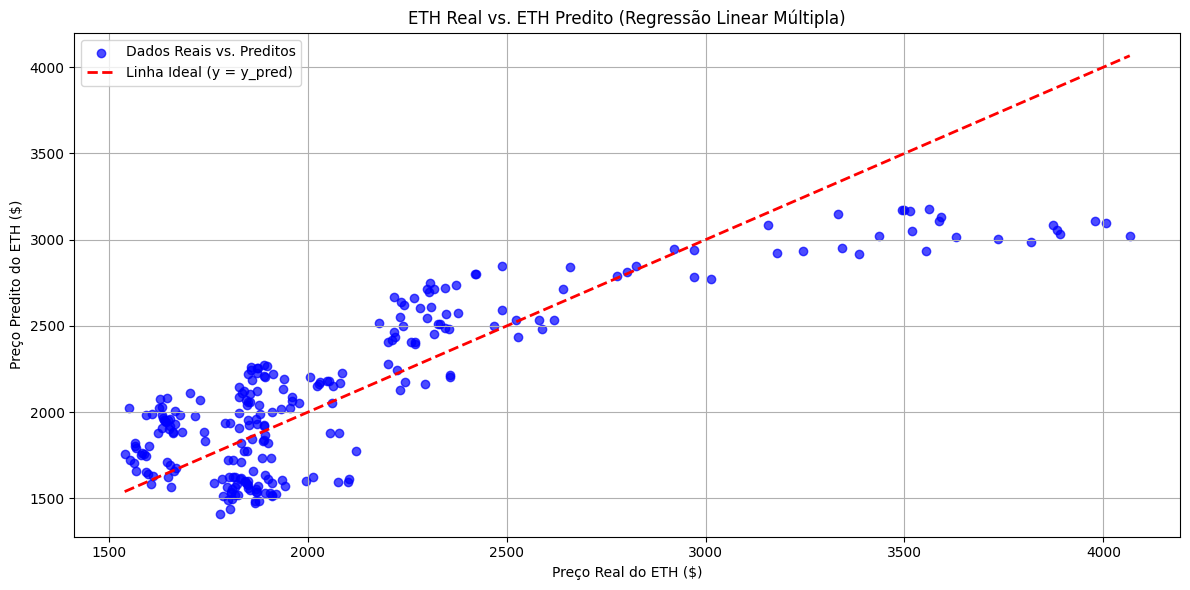

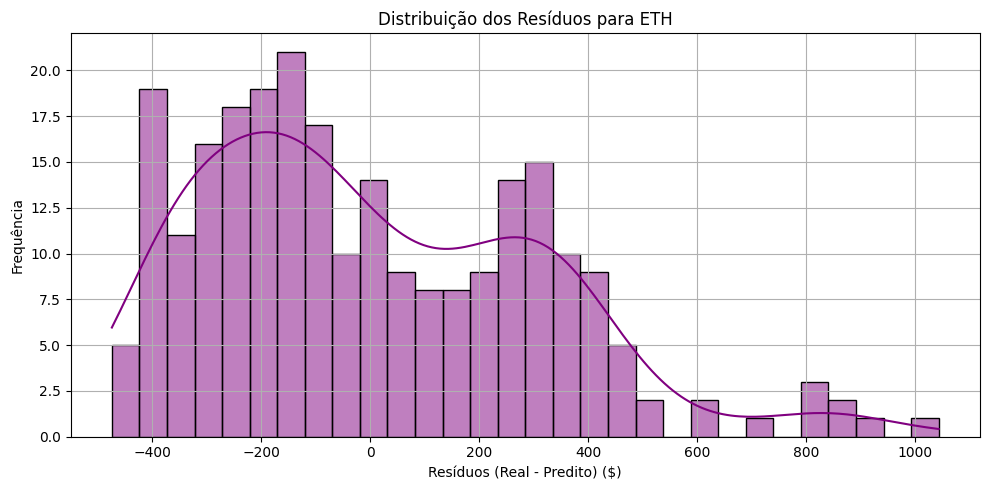

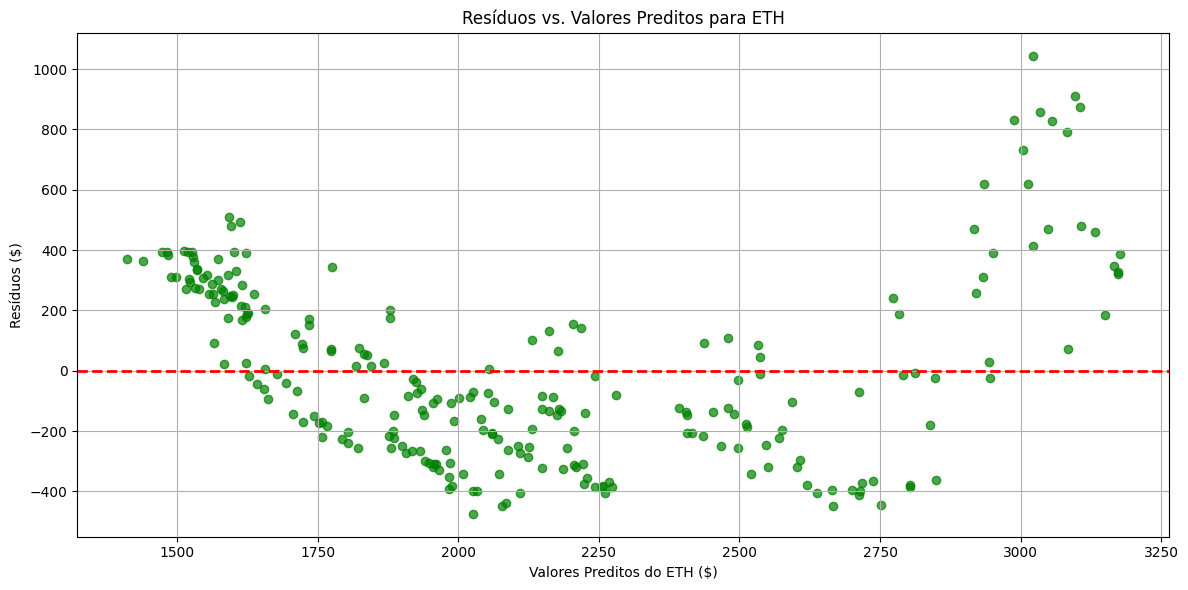

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


--- Equação da Regressão Múltipla para ETH ---
ETH_pred = -1531.1240 + 1.4989 * SP500 + -30.3086 * DXY

--- Exercício 4 (b): Coleta de novos valores (02 a 10 de abril de 2024) ---


Baixando dados de BTC (BTC-USD)...

Baixando dados de ETH (ETH-USD)...

Baixando dados de SP500 (^GSPC)...

Baixando dados de DXY (DX-Y.NYB)...
DataFrame 'df_teste' com dados de 02 a 10 de abril de 2024:


Price,BTC,date,ETH,SP500,DXY
Ticker,BTC-USD,,ETH-USD,^GSPC,DX-Y.NYB
0,65446.972656,2024-04-02,3277.234619,5205.810059,104.820000
1,65980.812500,2024-04-03,3311.441895,5211.490234,104.250000
2,68508.843750,2024-04-04,3330.040527,5147.209961,104.120003
3,67837.640625,2024-04-05,3318.885254,5204.339844,104.300003
4,71631.359375,2024-04-08,3695.292725,5202.390137,104.139999
5,69139.015625,2024-04-09,3505.163330,5209.910156,104.150002
6,70587.882812,2024-04-10,3543.737061,5160.640137,105.250000



--- Exercício 4 (c): Estimativa de ETH para os novos dados ---

DataFrame 'df_teste' com os valores de ETH estimados:


Price,BTC,date,ETH,SP500,DXY,ETH_Predito
Ticker,BTC-USD,,ETH-USD,^GSPC,DX-Y.NYB,
0,65446.972656,2024-04-02,3277.234619,5205.810059,104.820000,3095.044948
1,65980.812500,2024-04-03,3311.441895,5211.490234,104.250000,3120.834967
2,68508.843750,2024-04-04,3330.040527,5147.209961,104.120003,3028.423771
3,67837.640625,2024-04-05,3318.885254,5204.339844,104.300003,3108.601557
4,71631.359375,2024-04-08,3695.292725,5202.390137,104.139999,3110.528575
5,69139.015625,2024-04-09,3505.163330,5209.910156,104.150002,3121.497360
6,70587.882812,2024-04-10,3543.737061,5160.640137,105.250000,3014.305991


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression

# --- Exercício 4 (a): Regressão Linear Múltipla para ETH em função de SP500 e DXY ---
print("\n--- Exercício 4 (a): Regressão Linear Múltipla para ETH ---\n")

# Certifique-se que df_ativos está disponível
if 'df_ativos' not in locals() or df_ativos.empty:
    print("DataFrame 'df_ativos' não encontrado ou vazio. Carregando dados...")
    try:
        df_ativos = montar_dataframe_yfinance()
        print("DataFrame 'df_ativos' carregado com sucesso.")
    except NameError:
        print("Erro: A função 'montar_dataframe_yfinance' não está definida. Execute as células anteriores.")
        raise
    except Exception as e:
        print(f"Erro ao carregar df_ativos: {e}")
        raise

# 1. Preparar os dados
y_eth = df_ativos['ETH'].values.reshape(-1, 1) # Variável dependente (Preço do ETH)
X_eth_vars = df_ativos[['SP500', 'DXY']].values # Variáveis independentes

# Adicionar uma coluna de uns para o termo de intercepto (beta_0) na matriz X
X_eth = np.c_[np.ones(X_eth_vars.shape[0]), X_eth_vars]

# 2. Calcular os coeficientes de regressão usando o método de mínimos quadrados (forma matricial)
print("Calculando coeficientes de regressão para ETH...\n")
try:
    beta_coefficients_eth = np.linalg.inv(X_eth.T @ X_eth) @ X_eth.T @ y_eth
except np.linalg.LinAlgError:
    print("Erro: A matriz (X_eth.T @ X_eth) é singular. Utilizando LinearRegression do scikit-learn.")
    model_eth = LinearRegression()
    model_eth.fit(X_eth_vars, y_eth)
    beta_coefficients_eth = np.concatenate(([model_eth.intercept_], model_eth.coef_.flatten()))

# Extrair os coeficientes
beta_0_eth = beta_coefficients_eth[0][0]
beta_sp500_eth = beta_coefficients_eth[1][0]
beta_dxy_eth = beta_coefficients_eth[2][0]

print(f"Coeficiente Intercepto (beta_0): {beta_0_eth:.4f}")
print(f"Coeficiente SP500 (beta_1): {beta_sp500_eth:.4f}")
print(f"Coeficiente DXY (beta_2): {beta_dxy_eth:.4f}")

# 3. Fazer as previsões
y_pred_eth = X_eth @ beta_coefficients_eth

# 4. Analisar a qualidade das métricas numéricas
r_squared_eth = r2_score(y_eth, y_pred_eth)
mse_eth = mean_squared_error(y_eth, y_pred_eth)
rmse_eth = np.sqrt(mse_eth)
mae_eth = mean_absolute_error(y_eth, y_pred_eth)

print("\n--- Métricas Numéricas da Aproximação para ETH ---")
print(f"R² (Coeficiente de Determinação): {r_squared_eth:.4f}")
print(f"MSE (Erro Quadrático Médio): {mse_eth:.2f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse_eth:.2f}")
print(f"MAE (Erro Absoluto Médio): {mae_eth:.2f}")

# 5. Analisar a qualidade visual da aproximação

# Gráfico 1: Valores Reais vs. Valores Preditos
plt.figure(figsize=(12, 6))
plt.scatter(y_eth, y_pred_eth, alpha=0.7, color='blue', label='Dados Reais vs. Preditos')
plt.plot([y_eth.min(), y_eth.max()], [y_eth.min(), y_eth.max()], 'r--', lw=2, label='Linha Ideal (y = y_pred)')
plt.xlabel("Preço Real do ETH ($)")
plt.ylabel("Preço Predito do ETH ($)")
plt.title("ETH Real vs. ETH Predito (Regressão Linear Múltipla)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Cálculo e visualização dos resíduos
residuals_eth = y_eth.flatten() - y_pred_eth.flatten()

# Gráfico 2: Distribuição dos Resíduos
plt.figure(figsize=(10, 5))
sns.histplot(residuals_eth, kde=True, bins=30, color='purple')
plt.xlabel("Resíduos (Real - Predito) ($)")
plt.ylabel("Frequência")
plt.title("Distribuição dos Resíduos para ETH")
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico 3: Resíduos vs. Valores Preditos
plt.figure(figsize=(12, 6))
plt.scatter(y_pred_eth, residuals_eth, alpha=0.7, color='green')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel("Valores Preditos do ETH ($)")
plt.ylabel("Resíduos ($)")
plt.title("Resíduos vs. Valores Preditos para ETH")
plt.grid(True)
plt.tight_layout()
plt.show()

# Print da equação da reta de regressão múltipla
print("\n--- Equação da Regressão Múltipla para ETH ---")
print(f"ETH_pred = {beta_0_eth:.4f} + {beta_sp500_eth:.4f} * SP500 + {beta_dxy_eth:.4f} * DXY")

# --- Exercício 4 (b): Coleta de novos valores de 02 a 10 de abril de 2024 ---
print("\n--- Exercício 4 (b): Coleta de novos valores (02 a 10 de abril de 2024) ---\n")

# Coletar dados para o período de teste
# A data de fim precisa ser um dia depois da última data desejada
df_teste = montar_dataframe_yfinance(inicio='2024-04-02', fim='2024-04-11')
print("DataFrame 'df_teste' com dados de 02 a 10 de abril de 2024:")
display(df_teste)

# --- Exercício 4 (c): Estimar valores de ETH para os novos dados ---
print("\n--- Exercício 4 (c): Estimativa de ETH para os novos dados ---\n")

# Preparar os dados de teste (variáveis independentes SP500 e DXY)
X_test_eth_vars = df_teste[['SP500', 'DXY']].values
X_test_eth = np.c_[np.ones(X_test_eth_vars.shape[0]), X_test_eth_vars]

# Estimar os valores de ETH usando os coeficientes do modelo treinado
eth_pred_test = X_test_eth @ beta_coefficients_eth

# Adicionar as previsões ao df_teste
df_teste['ETH_Predito'] = eth_pred_test.flatten()

print("DataFrame 'df_teste' com os valores de ETH estimados:")
display(df_teste)


## **Exercício 5:** Refaça o exercício anterior considerando prever o preço do BTC em vez do preço da ETH.


--- Exercício 5: Regressão Linear Múltipla para BTC ---

Calculando coeficientes de regressão para BTC...

Coeficiente Intercepto (beta_0): -106901.2730
Coeficiente ETH (beta_1): 17.5435
Coeficiente SP500 (beta_2): 7.2621
Coeficiente DXY (beta_3): 707.4371

--- Métricas Numéricas da Aproximação para BTC ---
R² (Coeficiente de Determinação): 0.9674
MSE (Erro Quadrático Médio): 4802507.68
RMSE (Raiz do Erro Quadrático Médio): 2191.46
MAE (Erro Absoluto Médio): 1758.38


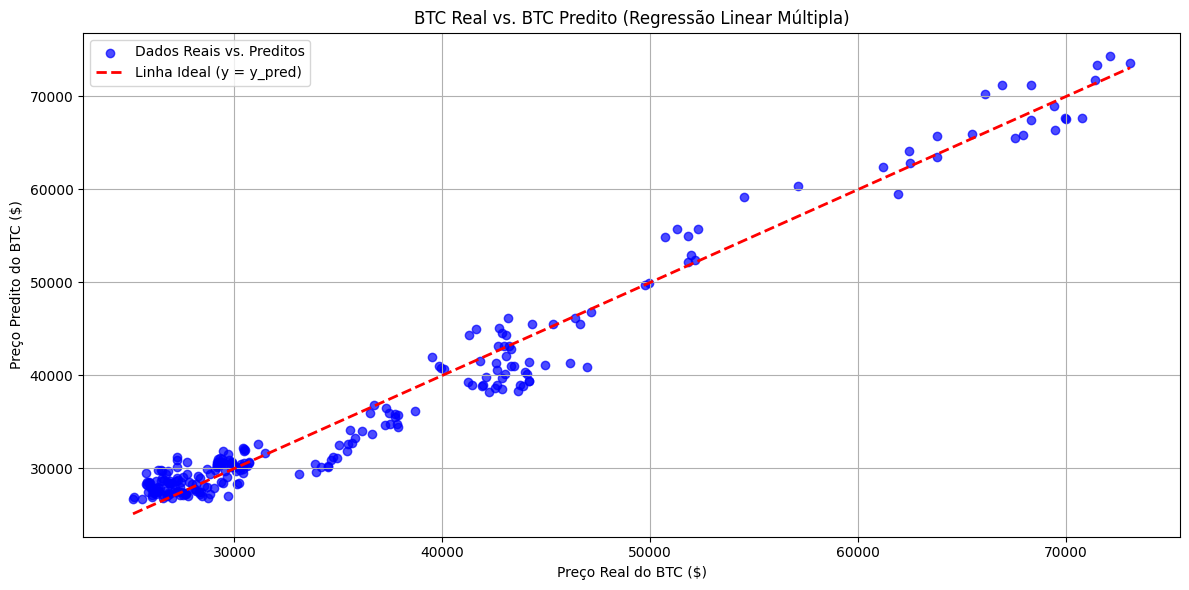

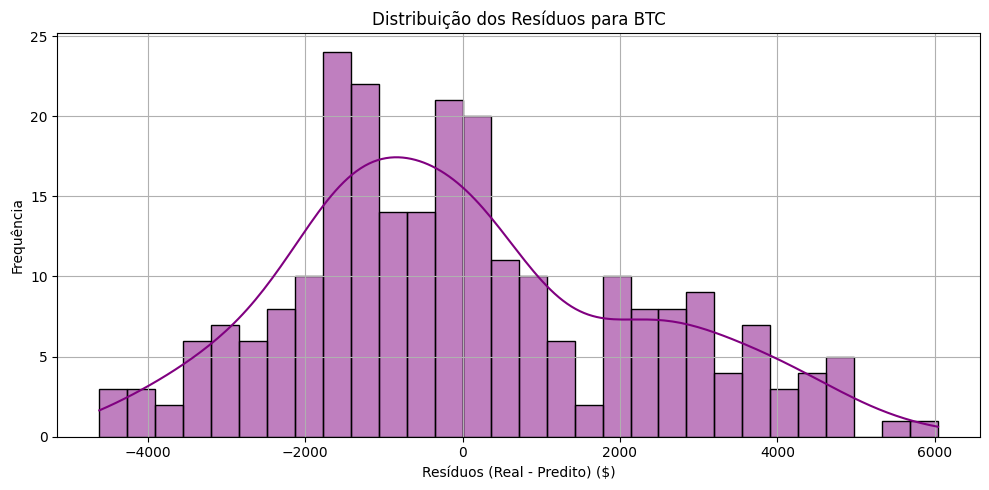

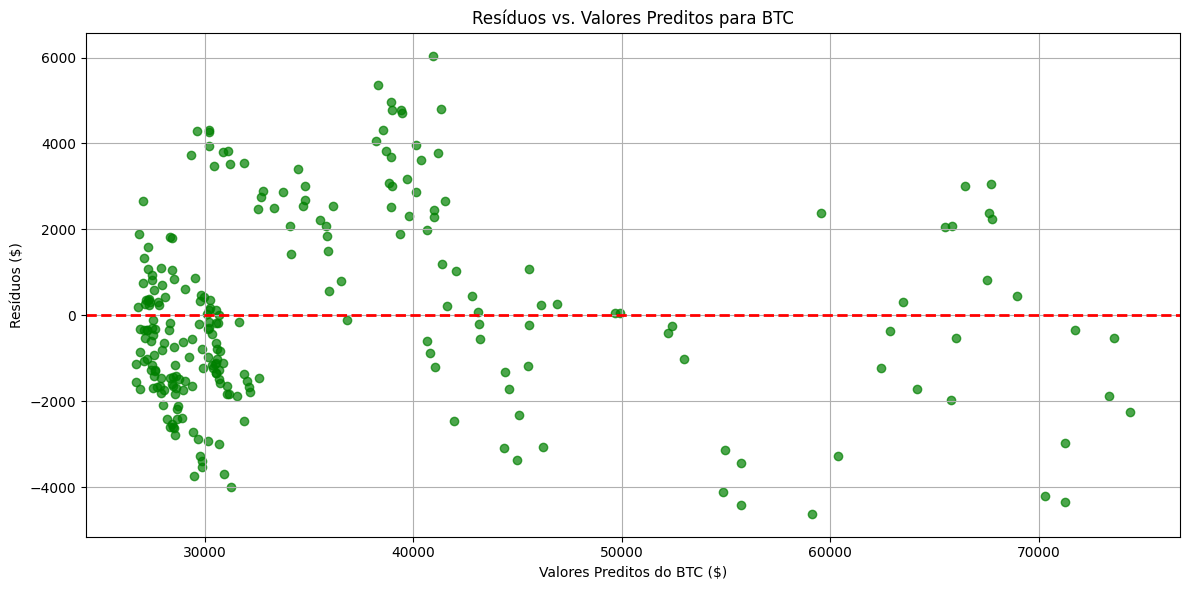


--- Equação da Regressão Múltipla para BTC ---
BTC_pred = -106901.2730 + 17.5435 * ETH + 7.2621 * SP500 + 707.4371 * DXY

--- Estimativa de BTC para os novos dados (02 a 10 de abril de 2024) ---

DataFrame 'df_teste' com os valores de BTC estimados:


Price,BTC,date,ETH,SP500,DXY,ETH_Predito,BTC_Predito
Ticker,BTC-USD,,ETH-USD,^GSPC,DX-Y.NYB,,
0,65446.972656,2024-04-02,3277.234619,5205.810059,104.820000,3095.044948,62551.530971
1,65980.812500,2024-04-03,3311.441895,5211.490234,104.250000,3120.834967,62789.657060
2,68508.843750,2024-04-04,3330.040527,5147.209961,104.120003,3028.423771,62557.167361
3,67837.640625,2024-04-05,3318.885254,5204.339844,104.300003,3108.601557,62903.686730
4,71631.359375,2024-04-08,3695.292725,5202.390137,104.139999,3110.528575,69379.836193
5,69139.015625,2024-04-09,3505.163330,5209.910156,104.150002,3121.497360,66105.989945
6,70587.882812,2024-04-10,3543.737061,5160.640137,105.250000,3014.305991,67203.083760


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression

# --- Exercício 5: Regressão Linear Múltipla para BTC em função de ETH, SP500 e DXY ---
print("\n--- Exercício 5: Regressão Linear Múltipla para BTC ---\n")

# Certifique-se que df_ativos está disponível
if 'df_ativos' not in locals() or df_ativos.empty:
    print("DataFrame 'df_ativos' não encontrado ou vazio. Carregando dados...")
    try:
        df_ativos = montar_dataframe_yfinance()
        print("DataFrame 'df_ativos' carregado com sucesso.")
    except NameError:
        print("Erro: A função 'montar_dataframe_yfinance' não está definida. Execute as células anteriores.")
        raise
    except Exception as e:
        print(f"Erro ao carregar df_ativos: {e}")
        raise

# 1. Preparar os dados para BTC
y_btc = df_ativos['BTC'].values.reshape(-1, 1) # Variável dependente (Preço do BTC)
X_btc_vars = df_ativos[['ETH', 'SP500', 'DXY']].values # Variáveis independentes

# Adicionar uma coluna de uns para o termo de intercepto (beta_0) na matriz X
X_btc = np.c_[np.ones(X_btc_vars.shape[0]), X_btc_vars]

# 2. Calcular os coeficientes de regressão usando o método de mínimos quadrados (forma matricial)
print("Calculando coeficientes de regressão para BTC...\n")
try:
    beta_coefficients_btc = np.linalg.inv(X_btc.T @ X_btc) @ X_btc.T @ y_btc
except np.linalg.LinAlgError:
    print("Erro: A matriz (X_btc.T @ X_btc) é singular. Utilizando LinearRegression do scikit-learn.")
    model_btc = LinearRegression()
    model_btc.fit(X_btc_vars, y_btc)
    beta_coefficients_btc = np.concatenate(([model_btc.intercept_], model_btc.coef_.flatten()))

# Extrair os coeficientes
beta_0_btc = beta_coefficients_btc[0][0]
beta_eth_btc = beta_coefficients_btc[1][0]
beta_sp500_btc = beta_coefficients_btc[2][0]
beta_dxy_btc = beta_coefficients_btc[3][0]

print(f"Coeficiente Intercepto (beta_0): {beta_0_btc:.4f}")
print(f"Coeficiente ETH (beta_1): {beta_eth_btc:.4f}")
print(f"Coeficiente SP500 (beta_2): {beta_sp500_btc:.4f}")
print(f"Coeficiente DXY (beta_3): {beta_dxy_btc:.4f}")

# 3. Fazer as previsões
y_pred_btc = X_btc @ beta_coefficients_btc

# 4. Analisar a qualidade das métricas numéricas
r_squared_btc = r2_score(y_btc, y_pred_btc)
mse_btc = mean_squared_error(y_btc, y_pred_btc)
rmse_btc = np.sqrt(mse_btc)
mae_btc = mean_absolute_error(y_btc, y_pred_btc)

print("\n--- Métricas Numéricas da Aproximação para BTC ---")
print(f"R² (Coeficiente de Determinação): {r_squared_btc:.4f}")
print(f"MSE (Erro Quadrático Médio): {mse_btc:.2f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse_btc:.2f}")
print(f"MAE (Erro Absoluto Médio): {mae_btc:.2f}")

# 5. Analisar a qualidade visual da aproximação

# Gráfico 1: Valores Reais vs. Valores Preditos
plt.figure(figsize=(12, 6))
plt.scatter(y_btc, y_pred_btc, alpha=0.7, color='blue', label='Dados Reais vs. Preditos')
plt.plot([y_btc.min(), y_btc.max()], [y_btc.min(), y_btc.max()], 'r--', lw=2, label='Linha Ideal (y = y_pred)')
plt.xlabel("Preço Real do BTC ($)")
plt.ylabel("Preço Predito do BTC ($)")
plt.title("BTC Real vs. BTC Predito (Regressão Linear Múltipla)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Cálculo e visualização dos resíduos
residuals_btc = y_btc.flatten() - y_pred_btc.flatten()

# Gráfico 2: Distribuição dos Resíduos
plt.figure(figsize=(10, 5))
sns.histplot(residuals_btc, kde=True, bins=30, color='purple')
plt.xlabel("Resíduos (Real - Predito) ($)")
plt.ylabel("Frequência")
plt.title("Distribuição dos Resíduos para BTC")
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico 3: Resíduos vs. Valores Preditos
plt.figure(figsize=(12, 6))
plt.scatter(y_pred_btc, residuals_btc, alpha=0.7, color='green')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel("Valores Preditos do BTC ($)")
plt.ylabel("Resíduos ($)")
plt.title("Resíduos vs. Valores Preditos para BTC")
plt.grid(True)
plt.tight_layout()
plt.show()

# Print da equação da reta de regressão múltipla
print("\n--- Equação da Regressão Múltipla para BTC ---")
print(f"BTC_pred = {beta_0_btc:.4f} + {beta_eth_btc:.4f} * ETH + {beta_sp500_btc:.4f} * SP500 + {beta_dxy_btc:.4f} * DXY")

# --- Utilizar df_teste (criado no Exercício 4) para estimar BTC para os novos dados ---
print("\n--- Estimativa de BTC para os novos dados (02 a 10 de abril de 2024) ---\n")

# Certifique-se que df_teste está disponível
if 'df_teste' not in locals() or df_teste.empty:
    print("DataFrame 'df_teste' não encontrado ou vazio. Carregando dados para o período de teste...")
    try:
        df_teste = montar_dataframe_yfinance(inicio='2024-04-02', fim='2024-04-11')
        print("DataFrame 'df_teste' carregado com sucesso.")
    except NameError:
        print("Erro: A função 'montar_dataframe_yfinance' não está definida. Execute as células anteriores.")
        raise
    except Exception as e:
        print(f"Erro ao carregar df_teste: {e}")
        raise

# Preparar os dados de teste (variáveis independentes ETH, SP500 e DXY)
X_test_btc_vars = df_teste[['ETH', 'SP500', 'DXY']].values
X_test_btc = np.c_[np.ones(X_test_btc_vars.shape[0]), X_test_btc_vars]

# Estimar os valores de BTC usando os coeficientes do modelo treinado
btc_pred_test = X_test_btc @ beta_coefficients_btc

# Adicionar as previsões ao df_teste
df_teste['BTC_Predito'] = btc_pred_test.flatten()

print("DataFrame 'df_teste' com os valores de BTC estimados:")
display(df_teste)


## **Exercício 6:** Adicione duas variáveis ao dataframe ```df_ativos``` que consistem na resposta logarítmica dos valores de fechamento do BTC e da ETH.

(a) Ajuste um modelo de regressão linear com $\log(\text{BTC})$ como variável resposta e $\log(\text{ETH})$ como preditor.

(b) Compare com o modelo linear simples do Exercício 2.

(c) Qual teve melhor ajuste? Os resíduos são mais apropriados? Justifique.

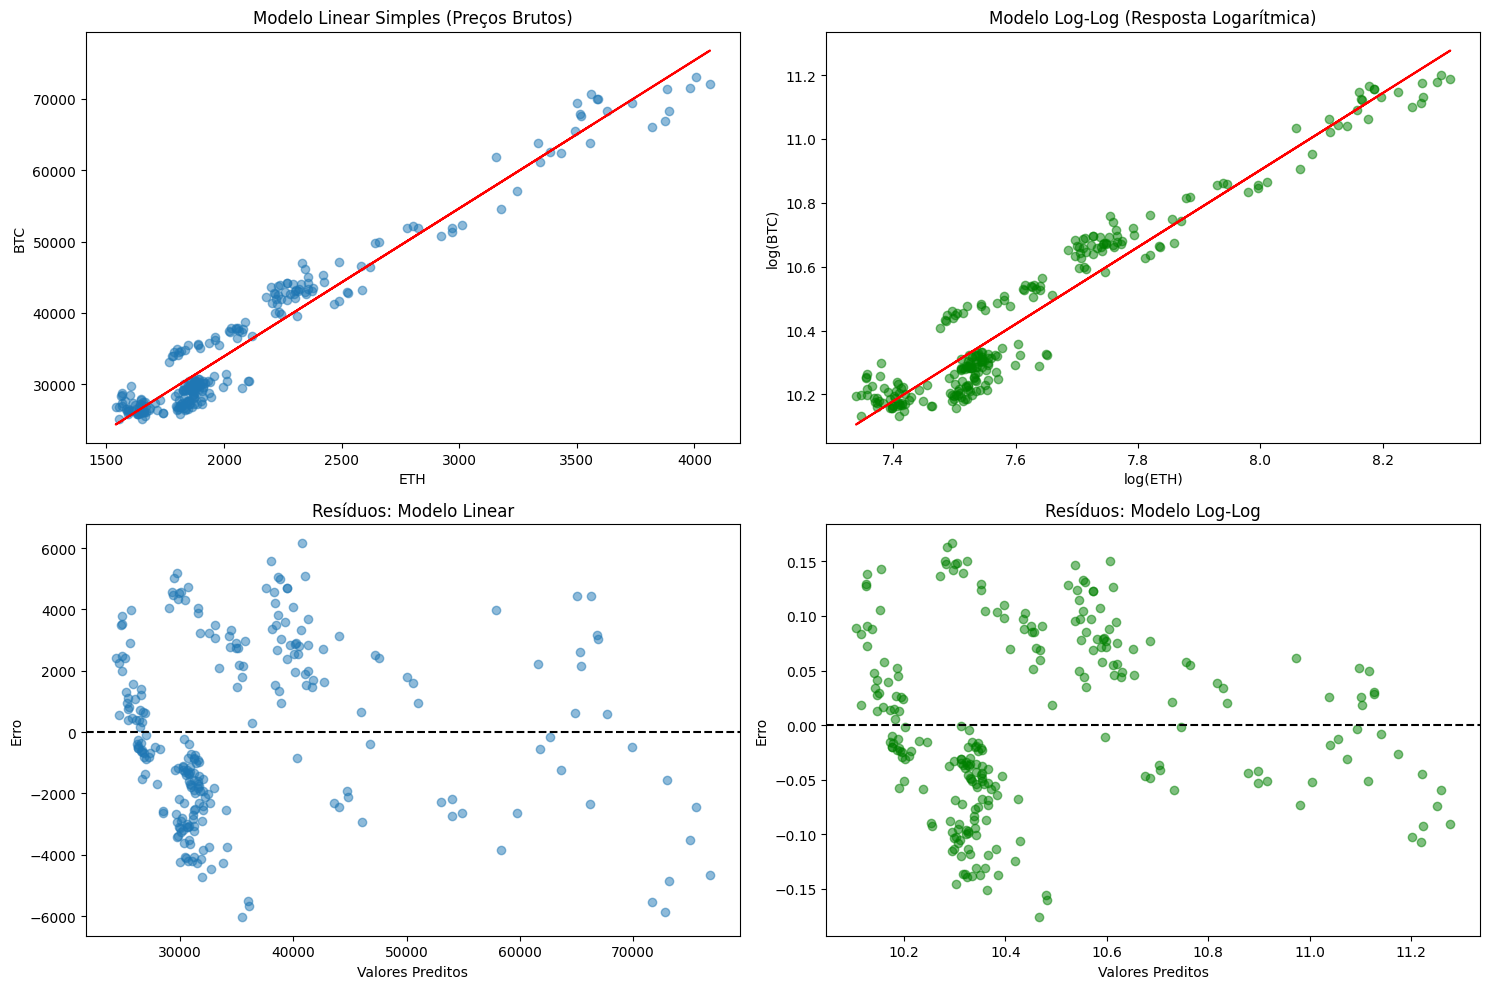

R² Linear: 0.9462
R² Log-Log: 0.9208


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Preparação dos Dados (Criação das variáveis logarítmicas)
df_ativos['log_btc'] = np.log(df_ativos['BTC'])
df_ativos['log_eth'] = np.log(df_ativos['ETH'])

def calcular_mprl(x, y):
    x_mean, y_mean = np.mean(x), np.mean(y)
    num = np.sum((x - x_mean) * (y - y_mean))
    den = np.sum((x - x_mean)**2)
    beta_1 = num / den
    beta_0 = y_mean - beta_1 * x_mean
    return beta_0, beta_1

# --- PARTE (a): Ajuste do Modelo Log-Log ---
x_log = df_ativos['log_eth'].values
y_log = df_ativos['log_btc'].values

b0_log, b1_log = calcular_mprl(x_log, y_log)
y_pred_log = b0_log + b1_log * x_log
residuos_log = y_log - y_pred_log

# --- Relembrando o Modelo Linear Simples (Exercício 2) para comparação ---
x_lin = df_ativos['ETH'].values
y_lin = df_ativos['BTC'].values

b0_lin, b1_lin = calcular_mprl(x_lin, y_lin)
y_pred_lin = b0_lin + b1_lin * x_lin
residuos_lin = y_lin - y_pred_lin

# --- PARTE (b) e (c): Visualização e Análise ---
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Gráfico Modelo Linear (Ex 2)
axes[0, 0].scatter(x_lin, y_lin, alpha=0.5)
axes[0, 0].plot(x_lin, y_pred_lin, color='red')
axes[0, 0].set_title('Modelo Linear Simples (Preços Brutos)')
axes[0, 0].set_xlabel('ETH')
axes[0, 0].set_ylabel('BTC')

# Gráfico Modelo Log-Log (Ex 6)
axes[0, 1].scatter(x_log, y_log, alpha=0.5, color='green')
axes[0, 1].plot(x_log, y_pred_log, color='red')
axes[0, 1].set_title('Modelo Log-Log (Resposta Logarítmica)')
axes[0, 1].set_xlabel('log(ETH)')
axes[0, 1].set_ylabel('log(BTC)')

# Resíduos Linear
axes[1, 0].scatter(y_pred_lin, residuos_lin, alpha=0.5)
axes[1, 0].axhline(y=0, color='black', linestyle='--')
axes[1, 0].set_title('Resíduos: Modelo Linear')
axes[1, 0].set_xlabel('Valores Preditos')
axes[1, 0].set_ylabel('Erro')

# Resíduos Log
axes[1, 1].scatter(y_pred_log, residuos_log, alpha=0.5, color='green')
axes[1, 1].axhline(y=0, color='black', linestyle='--')
axes[1, 1].set_title('Resíduos: Modelo Log-Log')
axes[1, 1].set_xlabel('Valores Preditos')
axes[1, 1].set_ylabel('Erro')

plt.tight_layout()
plt.show()

# Métricas rápidas para justificativa
r2_lin = 1 - (np.sum(residuos_lin**2) / np.sum((y_lin - np.mean(y_lin))**2))
r2_log = 1 - (np.sum(residuos_log**2) / np.sum((y_log - np.mean(y_log))**2))

print(f"R² Linear: {r2_lin:.4f}")
print(f"R² Log-Log: {r2_log:.4f}")

## **Exercício 7:** Investigue como a presença de covariáveis altamente correlacionadas afeta o desempenho e a confiabilidade de um modelo de regressão linear múltipla. Especificamente, avalie o impacto da **multicolinearidade** entre variáveis explicativas no MPRL.

**(a)** Crie uma nova variável chamada `ETH_noise`, somando um pequeno ruído gaussiano ao preço de fechamento do Ethereum:


$$ \text{ETH}_\text{noise} = \text{ETH}+\text{noise}. $$

**(b)** Ajuste um modelo de regressão linear múltipla para descrever o preço do Bitcoin (BTC) em função de ETH e ETH_noise:

$$ \text{BTC} ≈ \beta_0  +\beta_1\cdot \text{ETH} + \beta_2 \cdot \text{ETH}_\text{noise}. $$

**(c)** Analise e discuta:

- O valor de $ R^2 $ continua alto?  
- Os **coeficientes estimados** para `ETH` e `ETH_noise` são razoáveis ou parecem instáveis?  
- Algum coeficiente **perde significância estatística**?
- O que isso diz sobre a confiabilidade do modelo?

---

### 💬 Reflexão final:

> "Por que a presença de variáveis redundantes (altamente correlacionadas) pode ser prejudicial para o modelo de regressão linear? Como poderíamos mitigar esse problema?"

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     2181.
Date:                Mon, 27 Apr 2026   Prob (F-statistic):          2.92e-157
Time:                        18:24:00   Log-Likelihood:                -2330.1
No. Observations:                 249   AIC:                             4666.
Df Residuals:                     246   BIC:                             4677.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const              -7586.5373    689

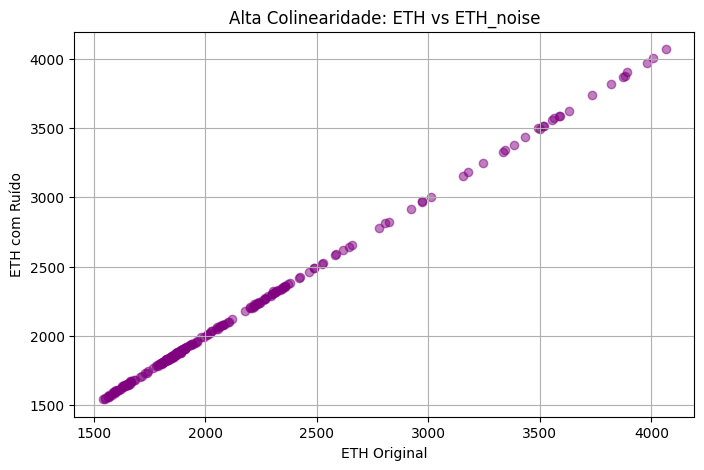

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 1. Garantindo que os dados sejam arrays unidimensionais para evitar o ValueError
# .flatten() garante que o array seja (n,) e não (n,1)
eth_vals = df_ativos['ETH'].values.flatten()
btc_vals = df_ativos['BTC'].values.flatten()

# (a) Criando a variável ETH_noise com ruído gaussiano
np.random.seed(42)
ruido = np.random.normal(0, 5, size=len(eth_vals))
eth_noise = eth_vals + ruido

# Adicionando de volta ao DataFrame para organização
df_ativos['ETH_noise'] = eth_noise

# (b) Ajustando o modelo de regressão linear múltipla (MPRL)
# Criamos a matriz X com as duas variáveis altamente correlacionadas
X = df_ativos[['ETH', 'ETH_noise']].astype(float)
X = sm.add_constant(X) # Adiciona a constante (Beta 0)
y = btc_vals

modelo = sm.OLS(y, X).fit()

# (c) Exibindo o sumário estatístico para análise
print(modelo.summary())

# --- Visualização Complementar (Análise de Correlação) ---
plt.figure(figsize=(8, 5))
plt.scatter(df_ativos['ETH'], df_ativos['ETH_noise'], alpha=0.5, color='purple')
plt.title('Alta Colinearidade: ETH vs ETH_noise')
plt.xlabel('ETH Original')
plt.ylabel('ETH com Ruído')
plt.grid(True)
plt.show()